In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.repair.rounding import RoundingRepair
from pymoo.optimize import minimize
from pymoo.operators.sampling.rnd import IntegerRandomSampling

import warnings
warnings.filterwarnings('ignore')

In [29]:
df = pd.read_excel('Individual Assignment Data File Electronic_sales.xlsx')
df.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56


In [30]:
orders = df[df['Order Status'] == 'Completed'].copy()
orders.reset_index(drop=True, inplace=True)
shipping_methods = orders['Shipping Type'].unique().tolist()

In [31]:
num_orders = 200
loyalty_multipliers = np.random.choice([1.0, 1.5], size=num_orders)
# costs = {'Standard': 5, 'Expedited': 15, 'Express': 25, 'Overnight': 30, 'Same Day': 50}
costs = np.array([5, 15, 25, 30, 50])  # Cost per shipping method
# Assumed baseline satisfaction scores per shipping method
base_satisfaction = np.array([3, 6, 8, 9, 10])  # Satisfaction scores per shipping method
# Daily warehouse capacity constraints for premium shipping
capacity = np.array([100, 50, 30, 20])  
# Capacity for each shipping method
cap_sameday = 20
cap_overnight = 30
cap_express = 60
cap_expedited = 100


In [32]:
class ShippingOptimization(ElementwiseProblem):
    def __init__(self, n_orders):
        super().__init__(n_var=n_orders, 
                         n_obj=2, # Two objectives: Cost and Satisfaction
                         n_ieq_constr=4, # Four capacity constraints
                         xl=np.zeros(n_orders), # Lower bound (0 = Standard)
                         xu=np.ones(n_orders) * 4, # Upper bound (4 = Same Day)
                         vtype=int) # Variables must be integers
        self.n_orders = n_orders

    def _evaluate(self, x, out, *args, **kwargs):
        # x is an array of size N containing integers [0, 1, 2, 3, or 4]
        # representing the assigned shipping method for each order.
        
        # Calculate Objective 1: Total Cost (Minimize)
        total_cost = np.sum(costs[x])
        
        # Calculate Objective 2: Total Satisfaction (Maximize)
        # Pymoo only minimizes, so we multiply by -1 to turn it into a minimization problem
        satisfaction_scores = base_satisfaction[x] * loyalty_multipliers
        total_satisfaction = -np.sum(satisfaction_scores)
        
        # Calculate Constraints (g <= 0)
        # Count how many orders were assigned 1 (Expedited), 2 (Express), and 3 (Overnight), 4 (Same Day)  
        count_expedited = np.count_nonzero(x == 1)
        count_sameday = np.count_nonzero(x == 4)
        count_overnight = np.count_nonzero(x == 3)
        count_express = np.count_nonzero(x == 2)

        
        # Constraint 1: Expedited <= Capacity --> (Count - Capacity <= 0)
        g1 = count_expedited - cap_expedited
        # Constraint 2: Same Day <= Capacity --> (Count - Capacity <= 0)
        g2 = count_sameday - cap_sameday
        # Constraint 3: Overnight <= Capacity --> (Count - Capacity <= 0)
        g3 = count_overnight - cap_overnight
        # Constraint 4: Express <= Capacity --> (Count - Capacity <= 0)
        g4 = count_express - cap_express
        
        
        out["F"] = [total_cost, total_satisfaction]
        out["G"] = [g1, g2, g3, g4]

In [33]:
problem = ShippingOptimization(n_orders=num_orders)

# Build a feasible initial population so NSGA-II starts within all 4 constraints
pop_size = 100
rng = np.random.default_rng(42)
initial_population = np.zeros((pop_size, num_orders), dtype=int)

for i in range(pop_size):
    order_idx = rng.permutation(num_orders)
    start = 0

    n_sameday = rng.integers(0, min(cap_sameday, num_orders - start) + 1)
    initial_population[i, order_idx[start:start + n_sameday]] = 4
    start += n_sameday

    n_overnight = rng.integers(0, min(cap_overnight, num_orders - start) + 1)
    initial_population[i, order_idx[start:start + n_overnight]] = 3
    start += n_overnight

    n_express = rng.integers(0, min(cap_express, num_orders - start) + 1)
    initial_population[i, order_idx[start:start + n_express]] = 2
    start += n_express

    n_expedited = rng.integers(0, min(cap_expedited, num_orders - start) + 1)
    initial_population[i, order_idx[start:start + n_expedited]] = 1

# Initialize NSGA-II tailored for Integer Variables
algorithm = NSGA2(
    pop_size=pop_size,
    sampling=initial_population,
    crossover=SBX(prob=0.9, eta=15, vtype=float, repair=RoundingRepair()),
    mutation=PM(eta=20, vtype=float, repair=RoundingRepair()),
    eliminate_duplicates=True
)

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 200),
               seed=42,
               verbose=False,
               return_least_infeasible=True)

# ==========================================
# 4. Extract and Visualize the Pareto Front
# ==========================================
if res.F is None:
    raise RuntimeError("Optimization returned no feasible or least-infeasible solution. Try increasing generations or relaxing capacities.")

F = np.atleast_2d(res.F)
X = np.atleast_2d(res.X)

# res.F contains the objective values for the Pareto Front
# Note: We must multiply satisfaction back by -1 to show positive values
costs_front = F[:, 0]
satisfaction_front = F[:, 1] * -1


# Extracting a specific optimal solution (e.g., the most balanced one)
# This finds the solution closest to the "middle" of the Pareto front
ideal_point = np.array([costs_front.min(), satisfaction_front.max()])
distances = np.sqrt((costs_front - ideal_point[0])**2 + (satisfaction_front - ideal_point[1])**2)
best_index = np.argmin(distances)

print("--- Balanced Compromise Solution ---")
print(f"Cost: ${costs_front[best_index]}")
print(f"Satisfaction: {satisfaction_front[best_index]}")

# You can extract the actual shipping assignments (0, 1, 2, 3, 4) for this solution:
best_assignments = X[best_index]
# orders['Assigned_Shipping_Int'] = best_assignments

--- Balanced Compromise Solution ---
Cost: $1660.0
Satisfaction: 1032.5


In [34]:
F_shape = np.atleast_2d(res.F).shape if res.F is not None else None
CV_vals = np.atleast_1d(res.CV) if hasattr(res, 'CV') and res.CV is not None else None
print('F shape:', F_shape)
print('CV min:', None if CV_vals is None else float(np.min(CV_vals)))
print('CV max:', None if CV_vals is None else float(np.max(CV_vals)))

F shape: (100, 2)
CV min: 0.0
CV max: 0.0


In [35]:
# Validate that the chosen compromise solution satisfies all 4 constraints
assigned = np.asarray(best_assignments).astype(int)

assigned_expedited = int(np.count_nonzero(assigned == 1))
assigned_express = int(np.count_nonzero(assigned == 2))
assigned_overnight = int(np.count_nonzero(assigned == 3))
assigned_sameday = int(np.count_nonzero(assigned == 4))

validation_df = pd.DataFrame({
    'Shipping Method': ['Expedited', 'Express', 'Overnight', 'Same Day'],
    'Assigned Orders': [assigned_expedited, assigned_express, assigned_overnight, assigned_sameday],
    'Capacity': [cap_expedited, cap_express, cap_overnight, cap_sameday]
})
validation_df['Slack (Capacity - Assigned)'] = validation_df['Capacity'] - validation_df['Assigned Orders']
validation_df['Constraint Satisfied'] = validation_df['Assigned Orders'] <= validation_df['Capacity']

all_constraints_satisfied = bool(validation_df['Constraint Satisfied'].all())
print('All 4 capacity constraints satisfied:', all_constraints_satisfied)
display(validation_df)

All 4 capacity constraints satisfied: True


,Shipping Method,Assigned Orders,Capacity,Slack (Capacity - Assigned),Constraint Satisfied
0,Expedited,58,100,42,True
1,Express,4,60,56,True
2,Overnight,0,30,30,True
3,Same Day,0,20,20,True


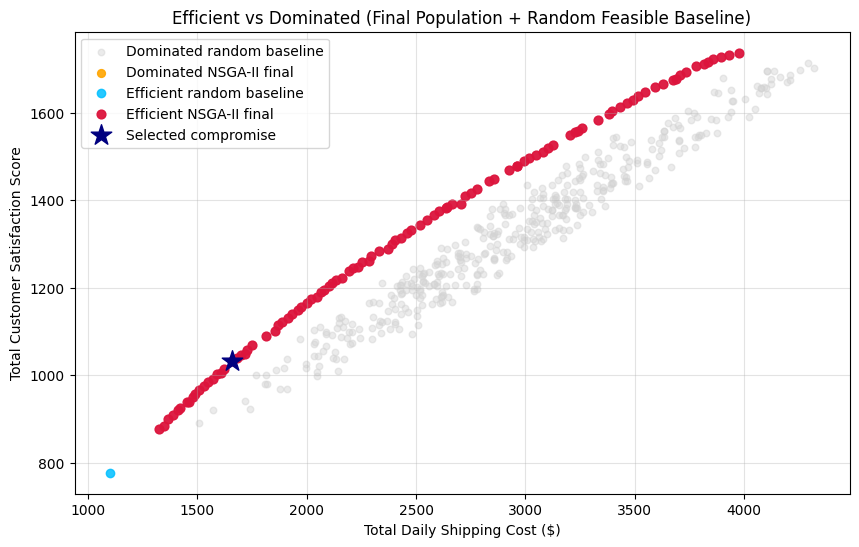

Total points: 500
Efficient points: 101
Dominated points: 399
Dominated NSGA-II final points: 0
Dominated random baseline points: 399


In [36]:
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# Add random feasible baseline solutions so dominated points are visible in the comparison
n_random = 400
rng_baseline = np.random.default_rng(2026)

random_X = np.zeros((n_random, num_orders), dtype=int)
for i in range(n_random):
    idx = rng_baseline.permutation(num_orders)
    start = 0

    n_sameday = rng_baseline.integers(0, min(cap_sameday, num_orders - start) + 1)
    random_X[i, idx[start:start + n_sameday]] = 4
    start += n_sameday

    n_overnight = rng_baseline.integers(0, min(cap_overnight, num_orders - start) + 1)
    random_X[i, idx[start:start + n_overnight]] = 3
    start += n_overnight

    n_express = rng_baseline.integers(0, min(cap_express, num_orders - start) + 1)
    random_X[i, idx[start:start + n_express]] = 2
    start += n_express

    n_expedited = rng_baseline.integers(0, min(cap_expedited, num_orders - start) + 1)
    random_X[i, idx[start:start + n_expedited]] = 1

# Evaluate random baseline with the same objectives
random_cost = np.sum(costs[random_X], axis=1)
random_sat = np.sum(base_satisfaction[random_X] * loyalty_multipliers, axis=1)
random_F = np.column_stack([random_cost, -random_sat])  # use minimization form to match pymoo F

# Final feasible population from NSGA-II
F_pop = np.asarray(res.pop.get('F'))
CV_pop = np.asarray(res.pop.get('CV')).reshape(-1)
feasible_mask = CV_pop <= 0
F_final_feasible = F_pop[feasible_mask]

# Combine final + random, then classify non-dominated vs dominated
F_all = np.vstack([F_final_feasible, random_F])
is_final = np.zeros(F_all.shape[0], dtype=bool)
is_final[:F_final_feasible.shape[0]] = True

nds = NonDominatedSorting()
efficient_idx_all = nds.do(F_all, only_non_dominated_front=True)
is_efficient_all = np.zeros(F_all.shape[0], dtype=bool)
is_efficient_all[efficient_idx_all] = True

is_dominated_all = ~is_efficient_all

x_all = F_all[:, 0]
y_all = -F_all[:, 1]  # back to maximize-satisfaction scale

plt.figure(figsize=(10, 6))
plt.scatter(
    x_all[~is_final & is_dominated_all], y_all[~is_final & is_dominated_all],
    s=22, alpha=0.45, color='lightgray', label='Dominated random baseline'
 )
plt.scatter(
    x_all[is_final & is_dominated_all], y_all[is_final & is_dominated_all],
    s=32, alpha=0.9, color='orange', label='Dominated NSGA-II final'
 )
plt.scatter(
    x_all[~is_final & is_efficient_all], y_all[~is_final & is_efficient_all],
    s=36, alpha=0.85, color='deepskyblue', label='Efficient random baseline'
 )
plt.scatter(
    x_all[is_final & is_efficient_all], y_all[is_final & is_efficient_all],
    s=40, alpha=0.95, color='crimson', label='Efficient NSGA-II final'
 )

plt.scatter(
    costs_front[best_index], satisfaction_front[best_index],
    marker='*', s=240, color='navy', label='Selected compromise'
 )

plt.title('Efficient vs Dominated (Final Population + Random Feasible Baseline)')
plt.xlabel('Total Daily Shipping Cost ($)')
plt.ylabel('Total Customer Satisfaction Score')
plt.grid(True, alpha=0.35)
plt.legend()
plt.show()

print('Total points:', int(F_all.shape[0]))
print('Efficient points:', int(np.sum(is_efficient_all)))
print('Dominated points:', int(np.sum(is_dominated_all)))
print('Dominated NSGA-II final points:', int(np.sum(is_final & is_dominated_all)))
print('Dominated random baseline points:', int(np.sum((~is_final) & is_dominated_all)))